In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from statsmodels.formula.api import ols
import mplcyberpunk as mpc

In [31]:
plt.style.use("cyberpunk")

# Ways of creating a dataframe:
## 1 - A dictionary of list of column values
Here `key` - column name & `val` - list of values for that column

In [32]:
# a dictionary of column : column_values
datadf1 = {"Name": ["Alice", "Bob" , "Charlie","Mike"],
        "Age": [26, 27,29,30],
        "City": ["New York" , "London" , "Paris","Los Angeles"],
        "join_date":["2025-10-01", "2024-09-23" , "2025-06-10" , "2025-01-10"]}

# Loading as a dataframe
df1 = pd.DataFrame(datadf1)

# Converting join_date column to datetime format
df1["join_date"] = pd.to_datetime(df1["join_date"])

print(df1.dtypes)
print(df1)

Name                    str
Age                   int64
City                    str
join_date    datetime64[us]
dtype: object
      Name  Age         City  join_date
0    Alice   26     New York 2025-10-01
1      Bob   27       London 2024-09-23
2  Charlie   29        Paris 2025-06-10
3     Mike   30  Los Angeles 2025-01-10


In [33]:
# Extracting only specific part of dates
df1["join_date"].dt.month_name()

0      October
1    September
2         June
3      January
Name: join_date, dtype: str

## Filtering rows / columns using `loc` & `iloc`

In [34]:
# Filtering based on iloc - works similar to lists indexing
df1.iloc[1, 1] = 28
print(df1)

      Name  Age         City  join_date
0    Alice   26     New York 2025-10-01
1      Bob   28       London 2024-09-23
2  Charlie   29        Paris 2025-06-10
3     Mike   30  Los Angeles 2025-01-10


In [35]:
# Creating a copy of the dataset
df2 = df1.copy()
df2.set_index("Name", inplace=True)

In [36]:
# filtering using loc - used for named indexes
df2.loc["Bob":"Mike",['Age','join_date']]

,Age,join_date
Name,,
Bob,28,2024-09-23
Charlie,29,2025-06-10
Mike,30,2025-01-10


# Probability revision

In [37]:
df = pd.read_csv('../statistics_in_python/stats_datasets/weightsheights.csv', usecols=["Height in cm" , "Weight in kg"]).round(2)
df.columns = df.columns.str.replace(' ', '_')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Height_in_cm  25000 non-null  float64
 1   Weight_in_kg  25000 non-null  float64
dtypes: float64(2)
memory usage: 390.8 KB


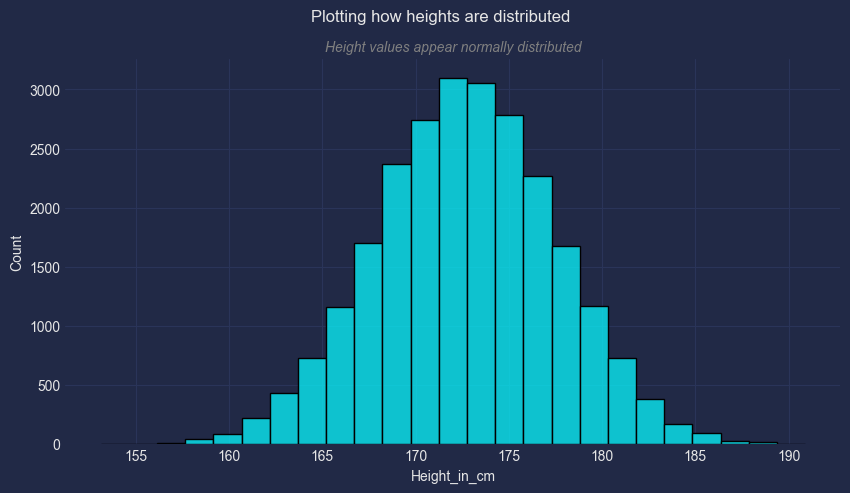

In [38]:
# Finding kind of distribution for the height values 
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="Height_in_cm", bins=25)
plt.suptitle("Plotting how heights are distributed")
plt.title("Height values appear normally distributed" , fontdict={'color':'grey', 'fontstyle':'italic', 'fontsize':10})
plt.show()

> Thus its observed that majority of heights are between 168-176 cm, quantiles will give better idea

In [39]:
the_quantiles = [0.25, 0.5 , 0.75, 1]

for each in the_quantiles: 
    print(f"Heights in {each}-ile : {np.quantile(df["Height_in_cm"],each)}")    


Heights in 0.25-ile : 169.43
Heights in 0.5-ile : 172.71
Heights in 0.75-ile : 175.95
Heights in 1-ile : 190.89


Text(0.5, 1.0, 'Overview of statistics using boxplot')

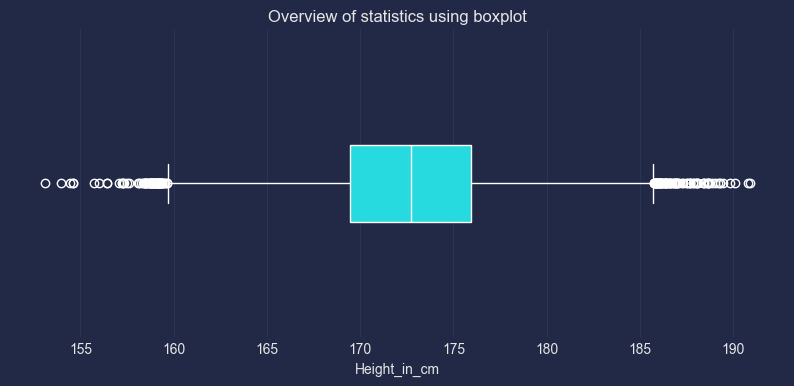

In [40]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x="Height_in_cm", width=0.25, flierprops={"markeredgecolor":"white"},linecolor='white')
plt.title("Overview of statistics using boxplot")

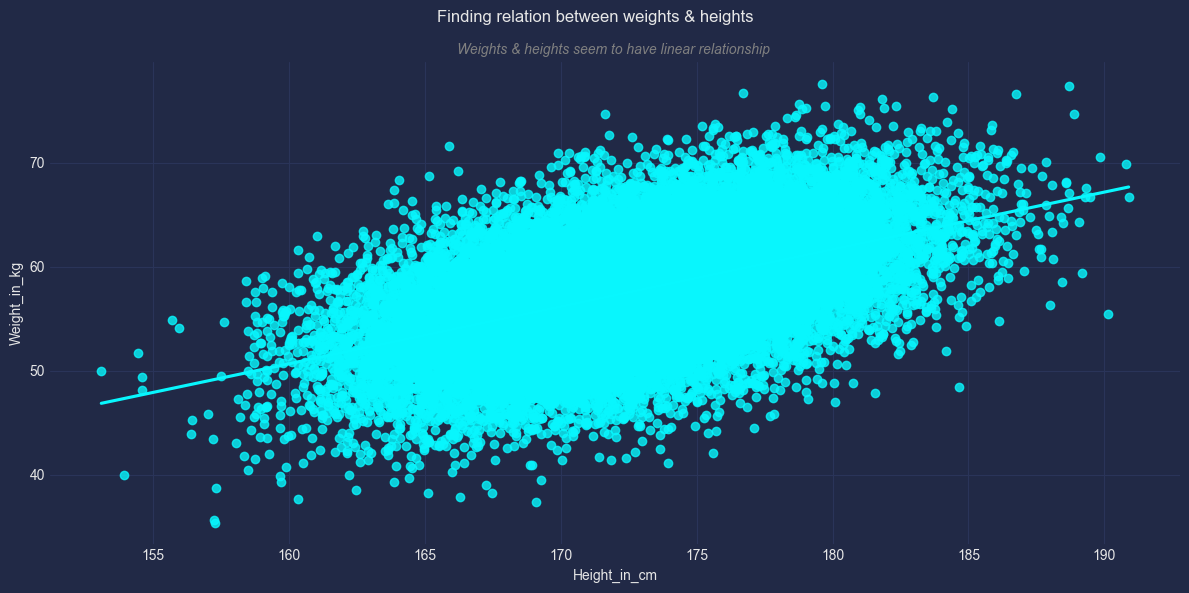

In [41]:
# Finding relation between weights & heights
plt.figure(figsize=(12,6))
sns.regplot(data=df , x= 'Height_in_cm' , y='Weight_in_kg', ci=None)
plt.suptitle('Finding relation between weights & heights')
plt.title("Weights & heights seem to have linear relationship " , fontdict={'color':'grey', 'fontstyle':'italic', 'fontsize':10})
plt.tight_layout()
plt.show()


## Determining the fit  

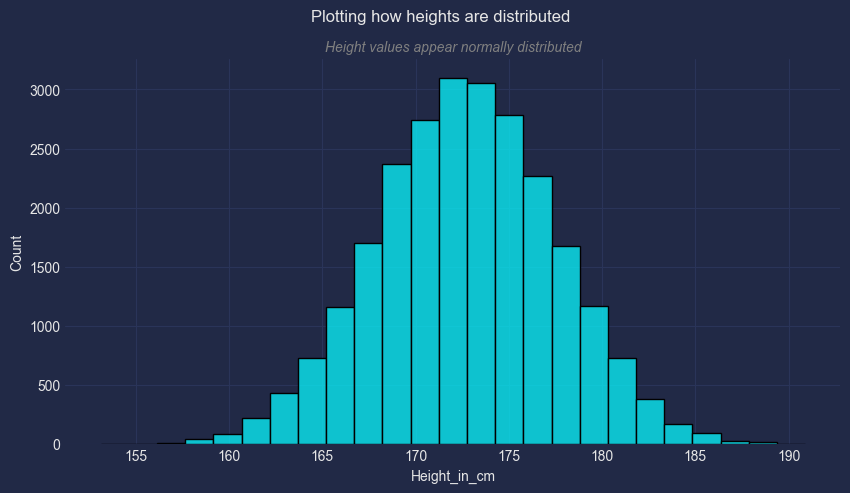

In [42]:
# Finding kind of distribution for the height values 
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="Height_in_cm", bins=25)
plt.suptitle("Plotting how heights are distributed")
plt.title("Height values appear normally distributed" , fontdict={'color':'grey', 'fontstyle':'italic', 'fontsize':10})
plt.show()


## Determining the fit  

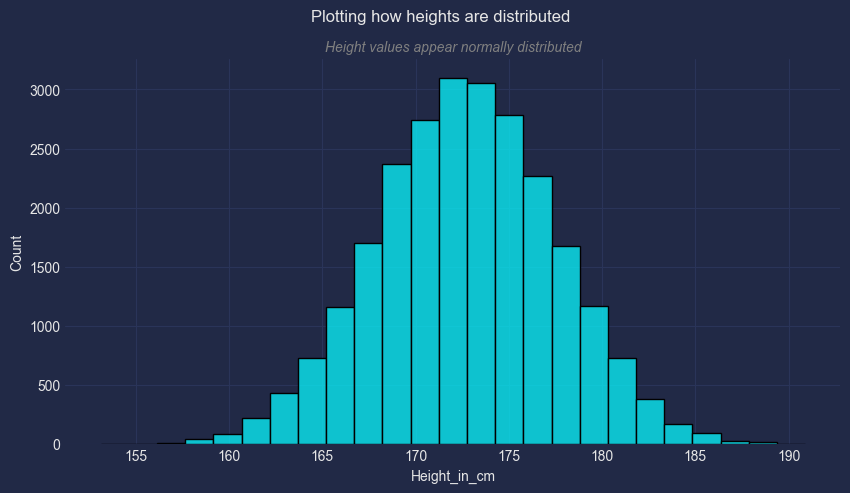

In [43]:
# Finding kind of distribution for the height values 
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="Height_in_cm", bins=25)
plt.suptitle("Plotting how heights are distributed")
plt.title("Height values appear normally distributed" , fontdict={'color':'grey', 'fontstyle':'italic', 'fontsize':10})
plt.show()


## Finding likelihood
**Q: What is the probability% that a person's height from the dataset < 172cm?**

In [44]:
height_mean = df.describe().loc["mean", "Height_in_cm"]
height_stdev  = df.describe().loc["std", "Height_in_cm"]

In [45]:
norm.cdf(172, loc= height_mean ,scale= height_stdev)

np.float64(0.44218866026199904)

>So there's a 44% chance that a person's height, selected randomly from the dataset, is less than 172cm .


**Q: What is the probability% that a person's height from the dataset > 178cm?**

In [46]:
1 - norm.cdf(178, loc=height_mean , scale=height_stdev)

np.float64(0.1363767033562957)

>So there's a 13.6% chance that a person's height, selected randomly from the dataset, is more than than 178cm .

**Q: What is the probability% that a person's height from the dataset is exactly 178cm?**

In [47]:
norm.pdf(178, loc=height_mean , scale=height_stdev)

np.float64(0.045263032907543306)

>So there's a 4.5% chance that a person's height, selected randomly from the dataset, is exactly 178cm .

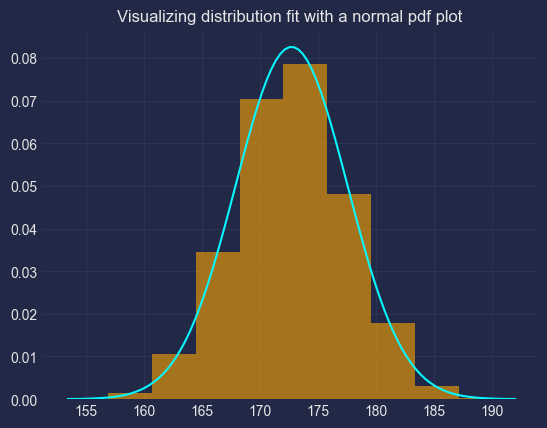

In [48]:
import scipy.stats

mu=height_mean
sigma=height_stdev

# calculating 100 evenly spaced intervals in a range
# of +/- 4 standard Deviations above / below the mean
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
y = norm.pdf(x, mu, sigma)
plt.hist(df["Height_in_cm"] , density=True, alpha=0.6, color='orange', label='Actual Data')
plt.title("Visualizing distribution fit with a normal pdf plot")
plt.plot(x,y)
plt.show()

If you were to run that same code with $n=500$:

- At $n=50$: Your histogram might look a bit "jagged," and the PDF curve is relatively wide.
- At $n=500$: The histogram bars would align almost perfectly with the PDF curve, and the entire structure would be much thinner and taller.

# Linear Regression
For the given `weightsheights.csv` dataset,consider:

- `height_in_cm` is explanatory (independent) variable

- `weight_in_kg` is response (dependent) variable

In [49]:
model = ols("Weight_in_kg ~ Height_in_cm", data=df).fit()
model.params

Intercept      -37.454069
Height_in_cm     0.550637
dtype: float64

### The linear equation formed is : 

Weight is calculated as: $Weight = (0.55\times Height) - 37.45$

>This means , for every 1cm increase in height, there's a 0.55X increase in the weight.

In [50]:
model.predict({"Height_in_cm":170})

0    56.154285
dtype: float64

___
# Revision of Sampling
>The method-2 (numpy + list comprehension) is fastest of the 3 methods listed below & also has minimal memory footprint. 

As for the other two, method-1(`for` loop) is simplest to understand.

In [51]:
# np.random.seed(2022)
# consider a normally-distributed dataset 
normaldf = pd.DataFrame({"val":np.round(np.random.normal(10,3.0,size=5000),2)})

### Method-1 : using `for` loop 
_using `for` loop  +  (`range` , `sample` & `mean`)  method_. 

This method is simplest to understand but compute time becomes longer as no. of samples / individual sample size grows.

**Output of below code:** each value represents a mean of one bootstrapped sample. So `bootstrapped_means` represents 1000 such means of bootstrapped samples


In [52]:
# taking bootstrapped samples
bootstrapped_means = []
for i in range(1000):
    # NOTE:size of bootstrapped sample is same as population
    bootstrapped_sample = normaldf.sample(frac=1, replace=True)
    bootstrapped_means.append(bootstrapped_sample["val"].mean())

print(len(bootstrapped_means))
print(bootstrapped_means[0:4])

1000
[np.float64(10.015944000000001), np.float64(10.048064000000002), np.float64(10.030166), np.float64(10.006288)]


In [53]:
# taking bootstrapped sample means of heights
btstrp_height = []
for i in range(1000):
    btstrp_heightsample = df.sample(frac=1, replace=True)
    btstrp_height.append(btstrp_heightsample["Height_in_cm"].mean())

print(len(btstrp_height))
print(btstrp_height[0:4])

1000
[np.float64(172.6862496), np.float64(172.70908079999998), np.float64(172.7625824), np.float64(172.6187736)]


## Method-2 : numpy conversion + list comprehension
**Code output:** is exact same as the above bootstrapping process, but its a _faster & compressed way that uses NumPy & a list comprehension_ instead of a standard `for` loop.

In [54]:
# converting the concerned column into a numpy array
heights_numpy = df['Height_in_cm'].to_numpy()
# perform sampling with replacement for 1000 times
heights_btstrpmean = [heights_numpy[np.random.randint(0,len(heights_numpy), len(heights_numpy))].mean().round(3) 
                      for _ in range(1000)]

print(f"dtype of heights_numpy : {type(heights_numpy)}")
print(f"dtype of heights_btrspmean : {type(heights_btstrpmean)}")
print(f"length of heights_btrspmean : {len(heights_btstrpmean)}")
print(f"heights_btrspmeans : {heights_btstrpmean[0:4]}")

dtype of heights_numpy : <class 'numpy.ndarray'>
dtype of heights_btrspmean : <class 'list'>
length of heights_btrspmean : 1000
heights_btrspmeans : [np.float64(172.665), np.float64(172.666), np.float64(172.735), np.float64(172.722)]


In [55]:
# this portion gives mean of one sample set (sampled with replacement)
heights_numpy[np.random.randint(0,len(heights_numpy),len(heights_numpy))].mean()

np.float64(172.68679439999997)

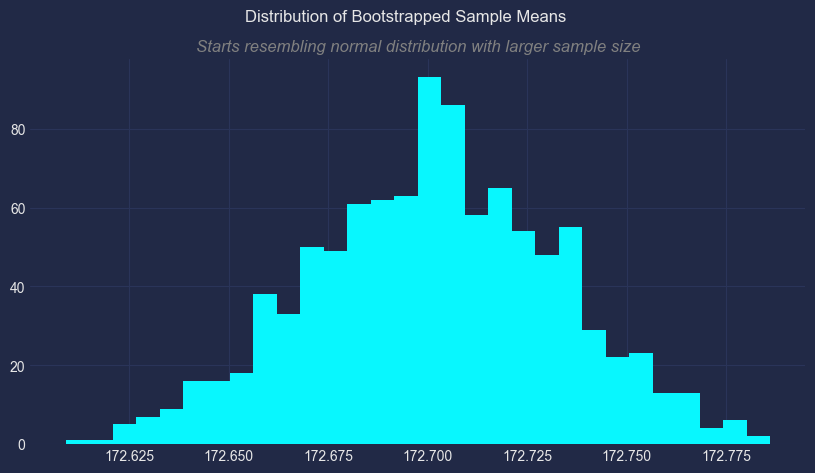

In [56]:
# plotting the distribution of the bootstrapped sample means
plt.figure(figsize=(10,5))
plt.hist(heights_btstrpmean, bins=30)
plt.title("Starts resembling normal distribution with larger sample size", fontdict={"style":"italic", "color":"grey"})
plt.suptitle("Distribution of Bootstrapped Sample Means")
plt.show()

>Proof that , as sampling size increases, the mean of all sampling mean approaches to the true population mean. (Law of large numbers) 

## Method-3 : using `scipy.stats` library's `bootstrap` module
Instead of building manual loops or index selectors, this method outsources the entire statistical process to a heavily optimized scientific library.

The scipy.stats library's `bootstrap` module contains the following params:
- `data` : df column to be sampled, it must be **passed as a Python tuple** of array-like objects
- `statistic` : tells SciPy exactly what metric you want to calculate for every single bootstrap sample (could be `np.mean` ,`np.median` etc.)
- `n_resamples` : number of bootstrapped samples to generate (default is 1000)
- `method` : the math formula to calculate the lower &  upper bounds of  confidence interval from the generated distribution.

**Output of below code:** is a `BootstrapResult` object that contains the confidence interval for the mean of the `height_in_cm` column, calculated from the bootstrapped samples. The confidence interval is typically represented as a tuple with lower and upper bounds.

In [57]:
# importing bootstrap module from scipy.stats
from scipy.stats import bootstrap
# converting concerned column into numpy array & tuple
data = (df['Height_in_cm'].to_numpy(), )
# create scipy.stats bootstrapped object
res = bootstrap(data= data, statistic=np.mean, n_resamples= 1000, method='percentile')
print(type(res))
# accessing the bootstrapped distribution
btsrp_samplemeans = res.bootstrap_distribution
print(type(btsrp_samplemeans))

<class 'scipy.stats._resampling.BootstrapResult'>
<class 'numpy.ndarray'>


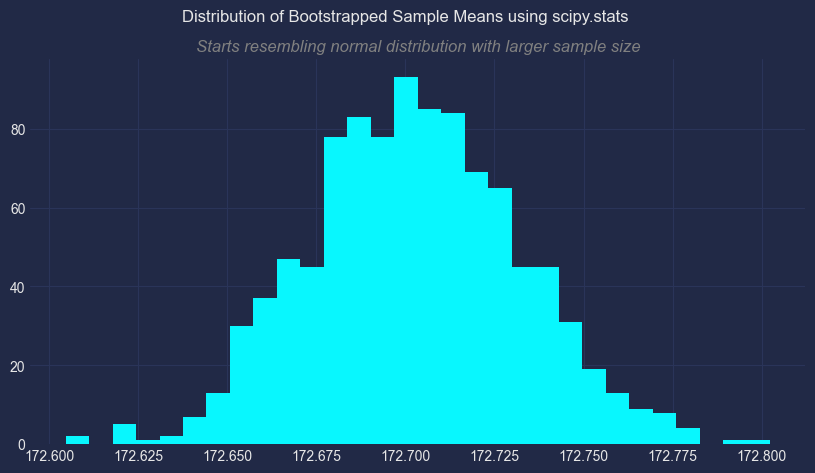

In [58]:
# plotting the btsrp distribution
plt.figure(figsize=(10,5))
plt.hist(btsrp_samplemeans, bins=30)
plt.title("Starts resembling normal distribution with larger sample size", fontdict={"style":"italic", "color":"grey"})
plt.suptitle("Distribution of Bootstrapped Sample Means using scipy.stats")
plt.show()

# Hypothesis testing
Its a statistical method that helps to determine if the data from sample provides enough evidence to support a specific claim about the larger population. 

A hypothesis test usually consists of 4 parts:
1. **The competing hypotheses** 

    a. **Null hypothesis (H0)**: This is the default assumption or claim that there is no effect or difference. It represents the status quo or a statement of no change.

    b **Alternative hypothesis (H1)**: This is the statement that contradicts the null
2. **Test-statistic**: Its a single numerical value calculated from sample data (z-score, t-score , f-statistic etc.) that measures how closely your observed data aligns with the null hypothesis.
3. **Significance value $(\alpha)$**: Its a pre-determined threshold for proof that's decided before looking at the data. Represents risk being taken of being wrong (Type I error / False positive - i.e. rejecting $H_0$ when it is actually true)

4. **The p-value**: the probability of observing your data, or something more extreme, under the assumption that $H_0$ is true. p-value is compared to the significance level $\alpha$ to decide whether to reject (p-value $\le \alpha$)  or fail to reject (p-value $> \alpha$) the null hypothesis.

### Errors in decision-making
1. **Type I Error /False positive ($\alpha$):** You reject the null hypothesis when it was actually true. (e.g., Convicting an innocent person, or concluding a drug works when it actually doesn't)

2. **Type II Error / False Negative ($\beta$):** You fail to reject the null hypothesis when it was actually false. (e.g., Letting a guilty person go free, or missing a breakthrough medical treatment because your sample size was too small).